In [46]:
import duckdb
import pandas as pd

conn = duckdb.connect("../data/processed/epl.duckdb", read_only=True)

def qfile(name: str) -> pd.DataFrame:
    with open(f"../sql/analysis/{name}") as f:
        return conn.sql(f.read()).df()

fresh = conn.sql(
    "SELECT * FROM refresh_log ORDER BY refreshed_at DESC LIMIT 1").df()
print(f"Data as of {fresh.loc[0,'refreshed_at']} · "
      f"GW{fresh.loc[0,'latest_gameweek']} · "
      f"{fresh.loc[0,'live_matches']} matches played")

Data as of 2026-09-23T09:48:37+00:00 · GW5 · 50 matches played


In [47]:

import matplotlib.pyplot as plt
import seaborn as sns

INK, ACCENT, MUTED, LINE = "#16191A", "#1F6A4A", "#5E6763", "#D6DAD2"
POS_COLORS = {"GKP": "#8C6D3F", "DEF": "#2F6F8F",
              "MID": "#1F6A4A", "FWD": "#A6452E"}

sns.set_theme(style="whitegrid", rc={
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.edgecolor": LINE,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titlecolor": INK,
    "grid.color": "#E4E7E0",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "legend.frameon": False,
})


def q(sql: str, params: tuple = ()) -> pd.DataFrame:
    """Ad-hoc query, for shaping a chart. Anything reusable belongs in sql/."""
    return conn.execute(sql, params).df()


def finish(ax, title: str, note: str = ""):
    """Title above, source note below. Every chart gets both."""
    ax.set_title(title, loc="left", pad=12)
    if note:
        ax.figure.text(0.01, -0.04, note, fontsize=9, color=MUTED)
    sns.despine(ax=ax, left=True)
    return ax

mean goals per match: 2.82
variance:             2.76
ft_result
H    44.2
D    23.8
A    32.0


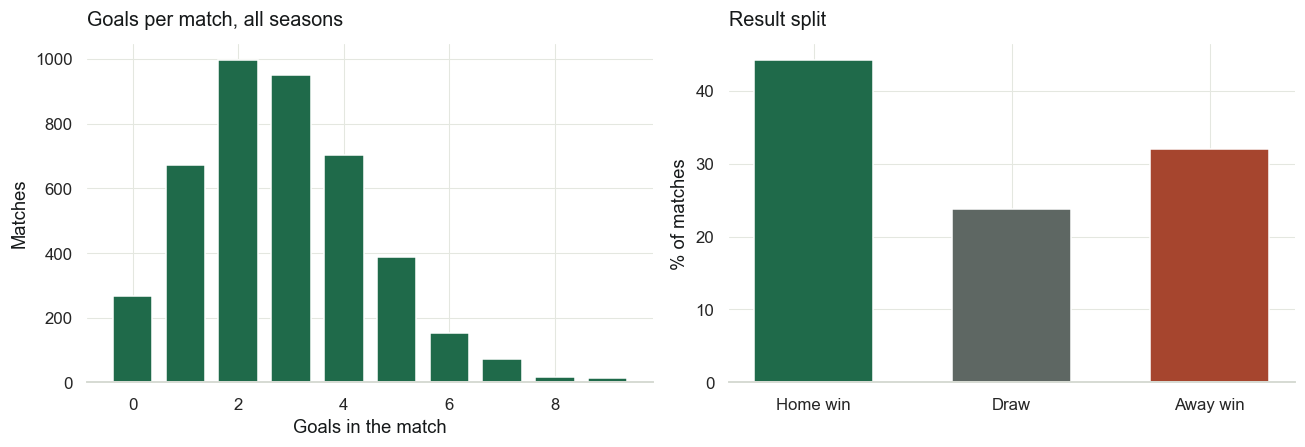

In [48]:
goals = q("""
    SELECT s.season_label, s.status, f.total_goals, f.ft_result
    FROM fact_match f
    JOIN dim_season s ON s.season_id = f.season_id
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = goals["total_goals"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=ACCENT, width=0.75)
axes[0].set_xlabel("Goals in the match")
axes[0].set_ylabel("Matches")
finish(axes[0], "Goals per match, all seasons")

split = (goals["ft_result"].value_counts(normalize=True)
         .reindex(["H", "D", "A"]) * 100)
axes[1].bar(["Home win", "Draw", "Away win"], split.values,
            color=[ACCENT, MUTED, "#A6452E"], width=0.6)
axes[1].set_ylabel("% of matches")
finish(axes[1], "Result split")

plt.tight_layout()
print(f"mean goals per match: {goals['total_goals'].mean():.2f}")
print(f"variance:             {goals['total_goals'].var():.2f}")
print(split.round(1).to_string())

          count  mean   50%   max
position                         
DEF        96.0  15.6  13.0  43.0
FWD        21.0  18.0  15.0  39.0
GKP        21.0  17.2  16.0  34.0
MID       105.0  16.6  15.0  47.0


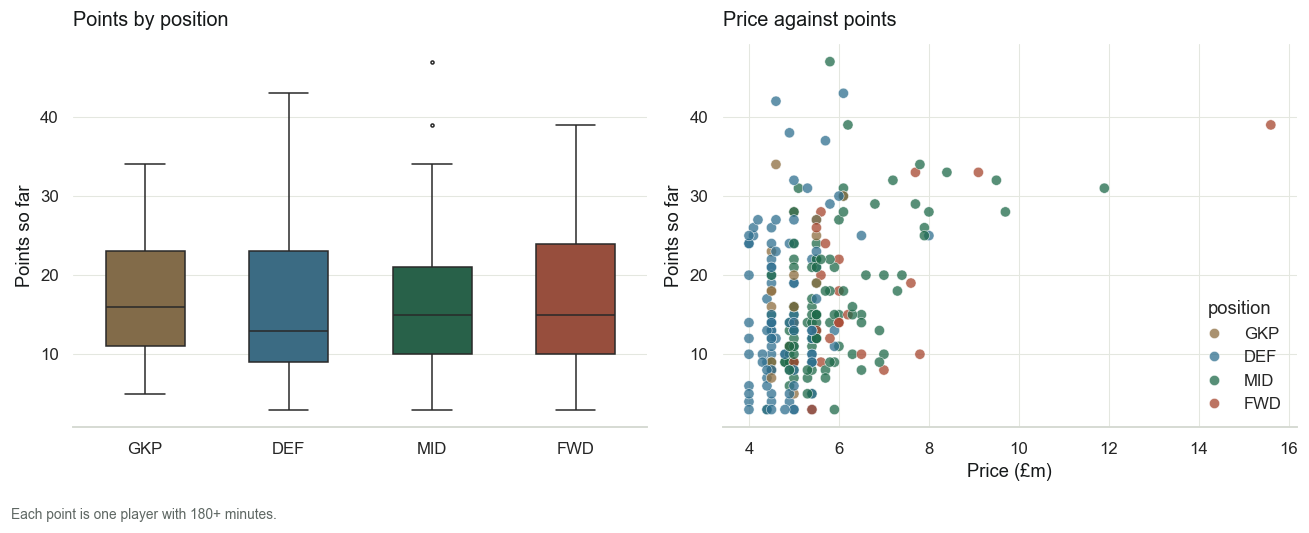

In [49]:
players = q("""
    SELECT web_name, position_short AS position, points AS total_points,
           price_m AS latest_price_m
    FROM player_season
    WHERE minutes >= 180
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))


order = ["GKP", "DEF", "MID", "FWD"]
sns.boxplot(data=players, x="position", y="total_points", order=order,
            hue="position", legend=False,
            palette=POS_COLORS, ax=axes[0], width=0.55, fliersize=2)
axes[0].set_xlabel("")
axes[0].set_ylabel("Points so far")
finish(axes[0], "Points by position")

sns.scatterplot(data=players, x="latest_price_m", y="total_points",
                hue="position", hue_order=order, palette=POS_COLORS,
                s=45, alpha=0.75, edgecolor="white", linewidth=0.4,
                ax=axes[1])
axes[1].set_xlabel("Price (£m)")
axes[1].set_ylabel("Points so far")
finish(axes[1], "Price against points",
       "Each point is one player with 180+ minutes.")

plt.tight_layout()
print(players.groupby("position")["total_points"]
      .describe()[["count", "mean", "50%", "max"]].round(1))

correlation price vs points: r = 0.391  (r squared = 0.153)
each extra £1m is worth about 2.8 points on this fit


,web_name,position,latest_price_m,total_points,expected,residual
9,Groß,MID,5.8,47.0,17.4,29.6
97,Bogle,DEF,4.6,42.0,14.1,27.9
84,Tarkowski,DEF,6.1,43.0,18.2,24.8
8,De Cuyper,DEF,4.9,38.0,14.9,23.1
54,Schade,MID,6.2,39.0,18.5,20.5
113,Tzolakis,GKP,4.6,34.0,14.1,19.9
209,Gvardiol,DEF,5.7,37.0,17.1,19.9
107,Vuskovic,DEF,5.0,32.0,15.2,16.8
94,Belloumi,MID,5.1,31.0,15.4,15.6
216,Hall,DEF,5.3,31.0,16.0,15.0


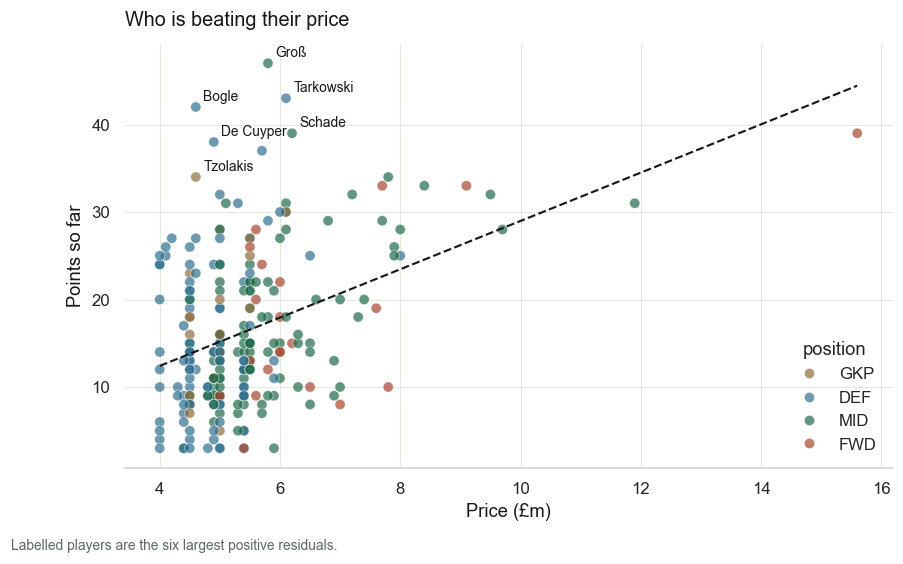

In [50]:
import numpy as np

x = players["latest_price_m"].to_numpy()
y = players["total_points"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
players["expected"] = slope * x + intercept
players["residual"] = y - players["expected"]

r = np.corrcoef(x, y)[0, 1]
print(f"correlation price vs points: r = {r:.3f}  (r squared = {r**2:.3f})")
print(f"each extra £1m is worth about {slope:.1f} points on this fit")

ax = sns.scatterplot(data=players, x="latest_price_m", y="total_points",
                     hue="position", hue_order=order, palette=POS_COLORS,
                     s=45, alpha=0.7, edgecolor="white", linewidth=0.4)
ax.plot(np.sort(x), slope * np.sort(x) + intercept,
        color=INK, linewidth=1.4, linestyle="--", label="linear fit")
for _, row in players.nlargest(6, "residual").iterrows():
    ax.annotate(row["web_name"],
                (row["latest_price_m"], row["total_points"]),
                xytext=(5, 4), textcoords="offset points",
                fontsize=9, color=INK)
ax.set_xlabel("Price (£m)")
ax.set_ylabel("Points so far")
finish(ax, "Who is beating their price",
       "Labelled players are the six largest positive residuals.")
players.nlargest(10, "residual")[
    ["web_name", "position", "latest_price_m", "total_points",
     "expected", "residual"]].round(1)

,position,players,never_played,under_90,pct_unusable
0,GKP,73,49.0,49.0,67.0
1,FWD,79,29.0,52.0,66.0
2,DEF,217,69.0,99.0,46.0
3,MID,298,99.0,171.0,57.0


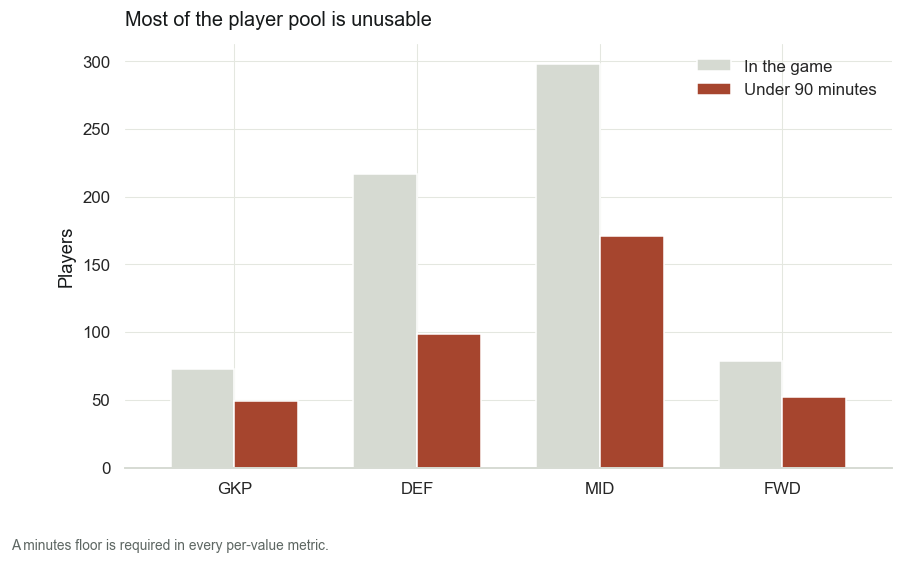

In [51]:
pool = q("""
    SELECT pos.position_short AS position,
           COUNT(*)                                            AS players,
           SUM(CASE WHEN m.mins IS NULL OR m.mins = 0
                    THEN 1 ELSE 0 END)                         AS never_played,
           SUM(CASE WHEN COALESCE(m.mins, 0) < 90
                    THEN 1 ELSE 0 END)                         AS under_90
    FROM dim_player p
    LEFT JOIN (SELECT player_id, SUM(minutes) AS mins
               FROM fact_player_fixture GROUP BY player_id) m
      ON m.player_id = p.player_id
    JOIN dim_position pos ON pos.position_id = p.position_id
    GROUP BY pos.position_short
""")
pool["pct_unusable"] = (100 * pool["under_90"] / pool["players"]).round(0)

ax = pool.set_index("position").loc[order, ["players", "under_90"]].plot(
    kind="bar", color=[LINE, "#A6452E"], width=0.7, rot=0)
ax.set_xlabel("")
ax.set_ylabel("Players")
ax.legend(["In the game", "Under 90 minutes"])
finish(ax, "Most of the player pool is unusable",
       "A minutes floor is required in every per-value metric.")
pool

bps          0.893
ict_index    0.673
goals        0.631
minutes      0.558
assists      0.463
price_m      0.367
Name: points, dtype: float64


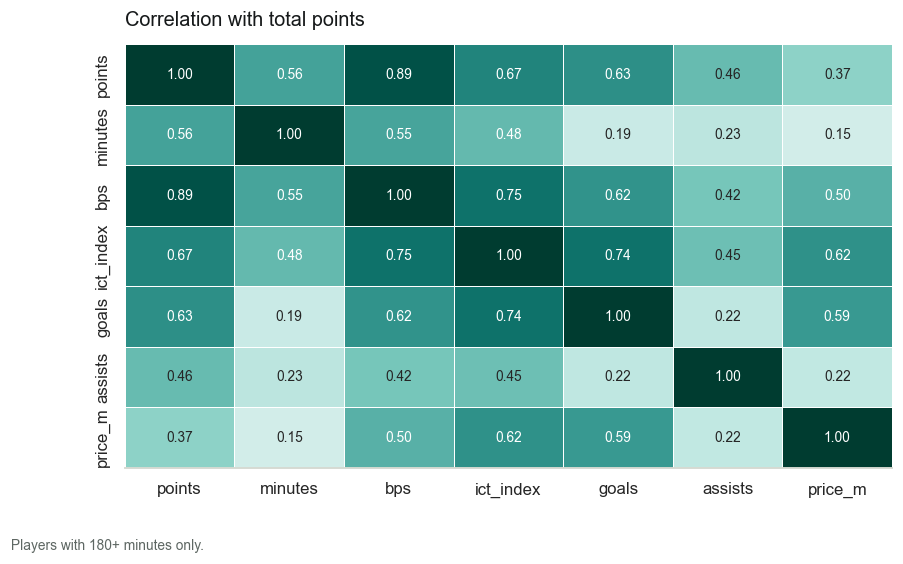

In [52]:
per_player = q("""
    SELECT SUM(f.total_points) AS points,
           SUM(f.minutes)    AS minutes,
           SUM(f.bps)        AS bps,
           AVG(f.ict_index)  AS ict_index,
           SUM(f.goals_scored) AS goals,
           SUM(f.assists)    AS assists,
           MAX(f.price_m)    AS price_m
    FROM fact_player_fixture f
    GROUP BY f.player_id
    HAVING SUM(f.minutes) >= 180
""")

corr = per_player.corr(numeric_only=True)
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="BrBG", center=0,
                 vmin=-1, vmax=1, linewidths=0.6, linecolor="white",
                 cbar=False, annot_kws={"size": 9})
finish(ax, "Correlation with total points",
       "Players with 180+ minutes only.")

print(corr["points"].drop("points").sort_values(ascending=False).round(3))

team_name
Fulham              2.4
Coventry City       2.4
Sunderland          2.6
Arsenal             2.8
AFC Bournemouth     2.8
Newcastle United    2.8
Crystal Palace      3.0
Manchester City     3.0
dtype: float64

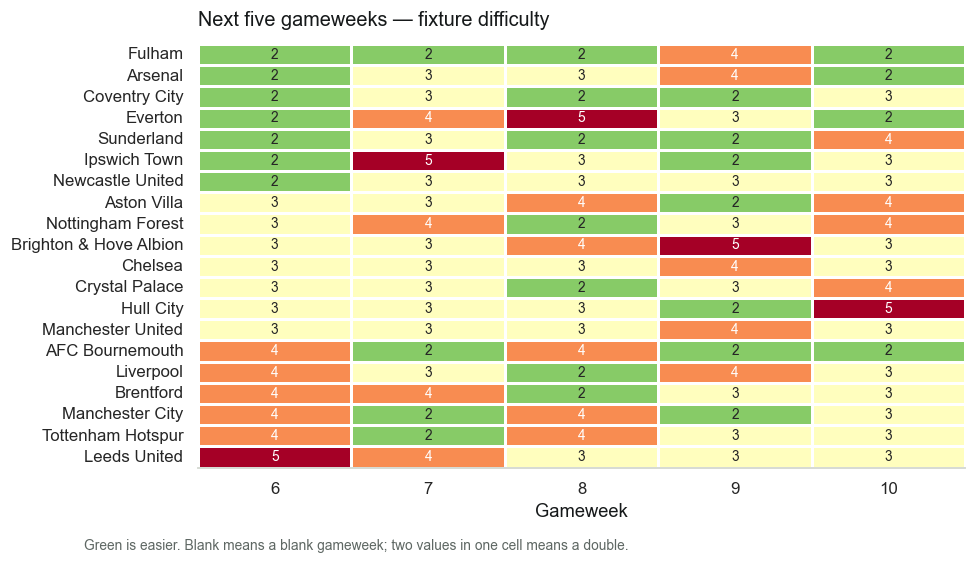

In [53]:
fdr = q("""
    SELECT t.team_name, x.gameweek_id, x.difficulty
    FROM fact_team_fixture x
    JOIN dim_team t ON t.team_id = x.team_id
    WHERE NOT x.finished
      AND x.gameweek_id <= (SELECT MIN(gameweek_id) + 4
                            FROM fact_team_fixture WHERE NOT finished)
""")
matrix = (fdr.pivot_table(index="team_name", columns="gameweek_id",
                          values="difficulty", aggfunc="mean")
          .sort_values(by=list(sorted(fdr["gameweek_id"].unique()))[0]))

ax = sns.heatmap(matrix, annot=True, fmt=".0f", cmap="RdYlGn_r",
                 vmin=1, vmax=5, linewidths=0.8, linecolor="white",
                 cbar=False, annot_kws={"size": 9})
ax.set_xlabel("Gameweek")
ax.set_ylabel("")
finish(ax, "Next five gameweeks — fixture difficulty",
       "Green is easier. Blank means a blank gameweek; two values in one "
       "cell means a double.")
matrix.mean(axis=1).sort_values().head(8).round(2)

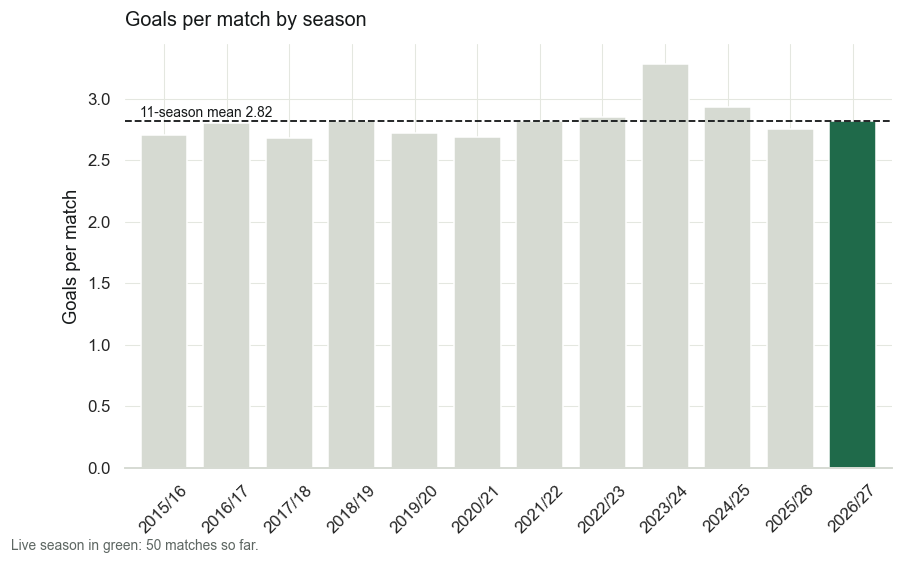

In [54]:
ctx = qfile("09_season_vs_baseline.sql")
live = ctx[ctx["status"] == "in_progress"].iloc[0]

colors = [ACCENT if s == "in_progress" else LINE for s in ctx["status"]]
ax = ctx.plot(kind="bar", x="season_label", y="goals_per_game",
              color=colors, width=0.75, legend=False, rot=45)
baseline = ctx.loc[ctx["status"] == "completed", "goals_per_game"].mean()
ax.axhline(baseline, color=INK, linestyle="--", linewidth=1.2)
ax.annotate(f"11-season mean {baseline:.2f}", (0.02, baseline + 0.03),
            xycoords=("axes fraction", "data"), fontsize=9, color=INK)
ax.set_xlabel("")
ax.set_ylabel("Goals per match")
finish(ax, "Goals per match by season",
       f"Live season in green: {int(live['matches'])} matches so far.")

if live["matches"] < 60:
    print(f"WARNING: only {int(live['matches'])} matches played. "
          "Any gap against the baseline is sampling variation, not a trend.")

## Findings

### 1. Price explains under half the variance in points
**Claim.** Price and points correlate at r = [X] (r squared [X]), so price accounts for
roughly [X]% of the variation. The players worth owning are the positive residuals,
and the six largest are [names].
**Evidence.** Cell 5, with the fitted line and labelled residuals.
**Caveat.** Price partly encodes expected minutes, so this conflates quality with
availability. The fit is also linear on a relationship that is probably not.
**So what.** Screen on residual, not on price. This is the column P2 predicts.

### 2. [X]% of the player pool has under 90 minutes
**Claim.** [X] of [Y] players have played less than one full match, concentrated in
[positions].
**Evidence.** Cell 6.
**Caveat.** This is season-to-date and shrinks every week, so the exact figure is a
snapshot rather than a stable property.
**So what.** Every per-value metric needs a minutes floor or it ranks unused
substitutes first. The floor in my SQL is 180 minutes, chosen because [reason].

### 3. Bonus points system score predicts points better than price does
**Claim.** bps correlates with total points at [X] against [X] for price.
**Evidence.** Cell 7 correlation matrix.
**Caveat.** bps is partly a function of points, so this is not an independent
predictor — it is closer to a restatement. Minutes drives both.
**So what.** P2 should use bps per 90 rather than raw bps, and must not treat these
inputs as independent.

### 4. Fixture difficulty clusters, so the next five gameweeks are not interchangeable
**Claim.** Average difficulty over the next five ranges from [X] to [X] across clubs.
**Evidence.** Cell 8 matrix.
**Caveat.** FPL's 1–5 rating is coarse and set before the season. It does not know
about injuries or current form, so it may not reflect real difficulty at all — which
is itself worth testing against goals conceded.
**So what.** Use it as one input, not as a ranking. Testing it properly is a P2 task.

### 5. The live season is not yet distinguishable from normal
**Claim.** Goals per match is [X] against an eleven-season mean of [X], on [X] matches.
**Evidence.** Cell 9.
**Caveat.** At this sample size the interval around the live figure comfortably
contains the baseline. There is no signal here yet.
**So what.** Nothing to act on, and saying so is the finding. Revisit at the winter
break when the sample supports a claim.

## Limitations

- Two seasons in the baseline were played without crowds, which affects home advantage
  and is not controlled for anywhere in this analysis.
- Past-season player data is not available from the official API, so nothing here is a
  multi-season player comparison.
- Fixture difficulty is FPL's own rating, not a measured quantity.
- Everything player-level is one partial season. Treat it as descriptive, not
  predictive.

## Next steps

Predicting points per player per gameweek, and picking a squad under the real budget
and position constraints. That is P2.